In the Shadows: Demo notebook

In [1]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-4.7.0.72-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (61.8 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
from scripts.bev_transform import bev_tranfom, inv_bev_transform
from scripts.apply_overlay import paste_overlay
import matplotlib.pyplot as plt
import cv2

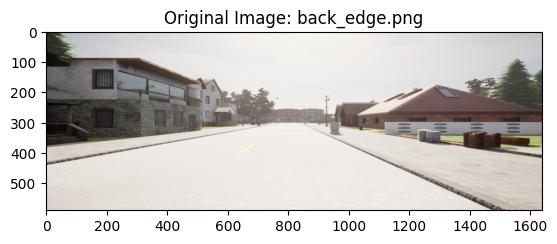

In [3]:
original_image_path = 'data/input/test/back_edge.png'
original_image_name = original_image_path[::-1].split("/")[0][::-1]
original_image = cv2.imread(original_image_path)
plt.title(f'Original Image: {original_image_name}')
plt.imshow(original_image[...,::-1])

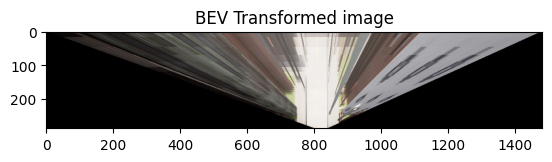

In [4]:
og, bev_img = bev_tranfom(original_image_path)
cv2.imwrite('post_bev.png', bev_img)
plt.title(f'BEV Transformed image')
plt.imshow(bev_img[...,::-1])

150 and, 146
Center (146, 27)
820 and, 669


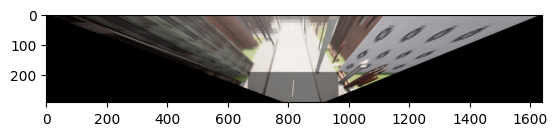

In [5]:
# Create Shadow and paste it onto image
# All values are in meters
shadow = {'width': 0.1, 'length': 2, 'alpha': 5, 'transparency': 128, 'blur': 1, 'distance': 0.2}
ov_bev = paste_overlay(shadow, bev_img)

cv2.imwrite('post_shadow.png', ov_bev)
plt.imshow(ov_bev[...,::-1])

Final shape (590, 1640, 3)


True

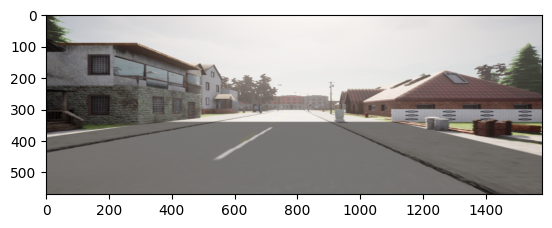

In [6]:
post_inv_bev_img = inv_bev_transform(original_image, ov_bev)
post_inv_bev_img = post_inv_bev_img[:570, 20:1600]
plt.imshow(post_inv_bev_img[...,::-1])
cv2.imwrite('postinvbev.png', post_inv_bev_img)